In [1]:
from pathlib import Path
from datetime import datetime, timedelta
import time

import requests
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob

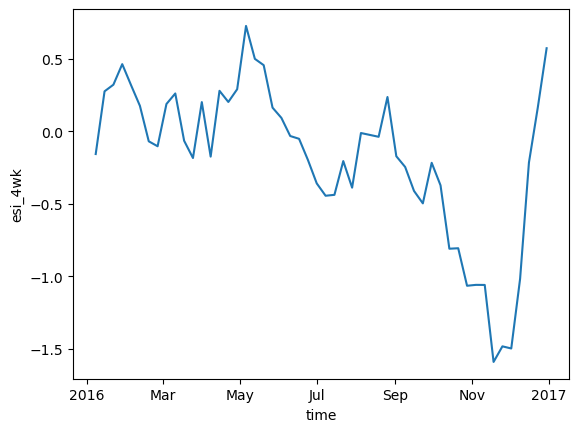

In [ ]:
#ESI
esi_4wk = xr.open_dataset('data/raw/esi/2016_4WK/esi_2016_4WK.nc')
esi_4wk.load()
x = (esi_4wk.where(esi_4wk > -9000)).count()
y =(esi_4wk == -9.999e+03).sum()
esi_4wk = esi_4wk.where(esi_4wk > -9000)
esi_regional_mean = esi_4wk["esi_4wk"].mean(dim=("lat", "lon"))
esi_regional_mean.plot()



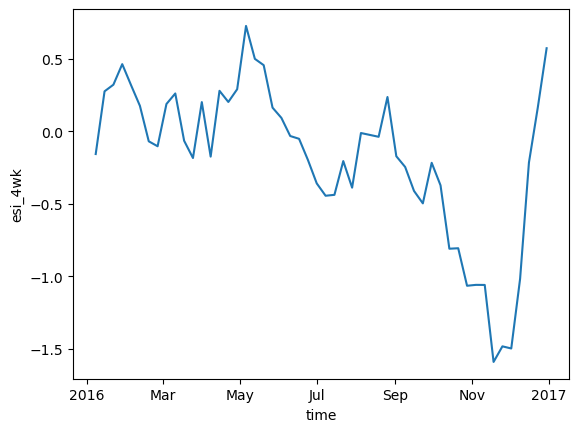

In [ ]:
esi_regional_mean_drought = esi_regional_mean.sel(time=slice("2016-08-01", "2016-12-31")
esi_regional_mean.plot()

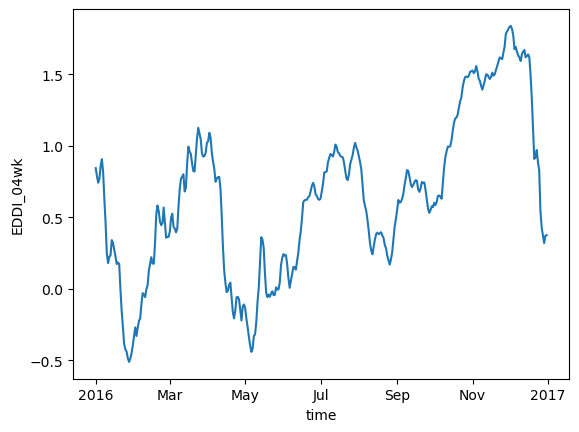

In [ ]:
#EDDI
ds = xr.open_dataset('data/intermediate/eddi_04wk_2016.nc')
ds.load()
eddi_04wk = ds['EDDI_04wk']
eddi_regional_mean = eddi_04wk.mean(dim=("lat", "lon"))
eddi_regional_mean = eddi_regional_mean.reset_coords("band", drop=True)

#eddi_regional_mean_drought = eddi_regional_mean.sel(time=slice("2016-08-01", "2016-12-31"))

eddi_regional_mean.plot()

In [ ]:
#coords and time
esi_regional_mean = esi_regional_mean.sortby("time")
eddi_regional_mean = eddi_regional_mean.sortby("time")
esi_regional_mean, eddi_regional_mean = xr.align(
    esi_regional_mean, eddi_regional_mean, join="inner")
# normalize
esi_norm = (esi_regional_mean - esi_regional_mean.mean()) / esi_regional_mean.std()
eddi_norm = (eddi_regional_mean - eddi_regional_mean.mean()) / eddi_regional_mean.std()

esi_norm = -1 * esi_norm

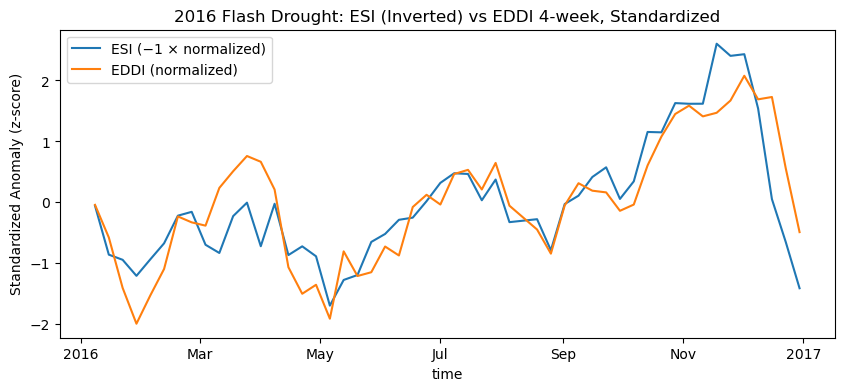

In [41]:
fig, ax = plt.subplots(figsize=(10,4))



esi_norm.plot(ax=ax, label="ESI (−1 × normalized)")
eddi_norm.plot(ax=ax, label="EDDI (normalized)")

ax.set_title(
    "2016 Flash Drought: ESI (Inverted) vs EDDI 4-week, Standardized"
)
ax.set_ylabel("Standardized Anomaly (z-score)")
ax.legend()
plt.show()

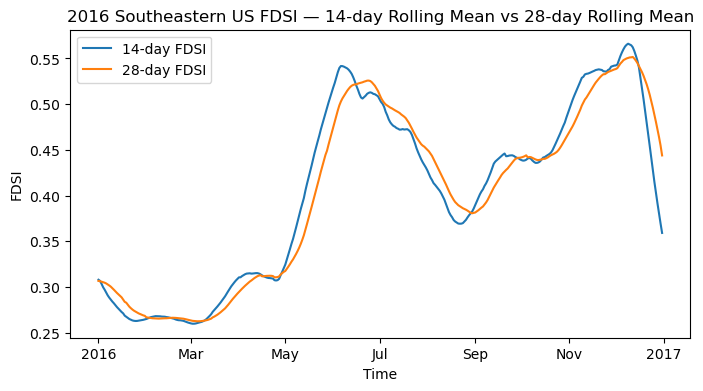

In [ ]:
#FDSI

lat_min, lat_max = 30, 35
lon_min, lon_max = -89.0, -81.6

ds = xr.open_dataset("FDSI.nc", decode_times=False)

time_vals = ds["Time"].values.astype(str)
time_parsed = pd.to_datetime(time_vals, format="%Y%m%d", errors="coerce")

ds = ds.assign_coords(Time=time_parsed)



ds_2016 = ds.sel(Time=slice('2016-01-01','2016-12-31'), Latitude=slice(lat_max, lat_min), Longitude = slice(lon_min, lon_max))

ds_2016
#rolling means 


fdsi_roll_14 = ds['FDSI'].rolling(Time=14).mean()
fdsi_roll_28 = ds['FDSI'].rolling(Time=28,).mean()

#2016
region_14 = fdsi_roll_14.sel(Time=slice('2016-01-01','2016-12-31'), Latitude=slice(lat_max, lat_min), Longitude = slice(lon_min, lon_max))
region_28 = fdsi_roll_28.sel(Time=slice('2016-01-01','2016-12-31'), Latitude=slice(lat_max, lat_min), Longitude = slice(lon_min, lon_max))

fig, ax = plt.subplots(figsize=(8, 4))

region_14.mean(dim=['Latitude','Longitude']).plot(ax=ax, label='14-day FDSI')
region_28.mean(dim=['Latitude','Longitude']).plot(ax=ax, label='28-day FDSI')
ax.set_title("2016 Southeastern US FDSI — 14-day Rolling Mean vs 28-day Rolling Mean")
ax.set_xlabel("Time")
ax.set_ylabel("FDSI")
ax.legend()

plt.show()


In [ ]:
#find the regional mean and normalize fdsi against esi and eddi
fdsi_regional_mean = region_14.mean(
    dim=["Latitude", "Longitude"],
    skipna=True
)

fdsi_regional_mean = fdsi_regional_mean.rename({"Time": "time"})
esi_regional_mean = esi_regional_mean.sortby("time")
eddi_regional_mean = eddi_regional_mean.sortby("time")
fdsi_regional_mean = fdsi_regional_mean.sortby("time")


esi_regional_mean, eddi_regional_mean, fdsi_regional_mean = xr.align(esi_regional_mean, eddi_regional_mean, fdsi_regional_mean, join="inner")

#normalize
esi_norm = (esi_regional_mean - esi_regional_mean.mean()) / esi_regional_mean.std()
eddi_norm = (eddi_regional_mean - eddi_regional_mean.mean()) / eddi_regional_mean.std()
fdsi_norm = (fdsi_regional_mean - fdsi_regional_mean.mean()) / fdsi_regional_mean.std()
#inversion of ESI to make it uniform 
esi_norm_flipped = -1 * esi_norm

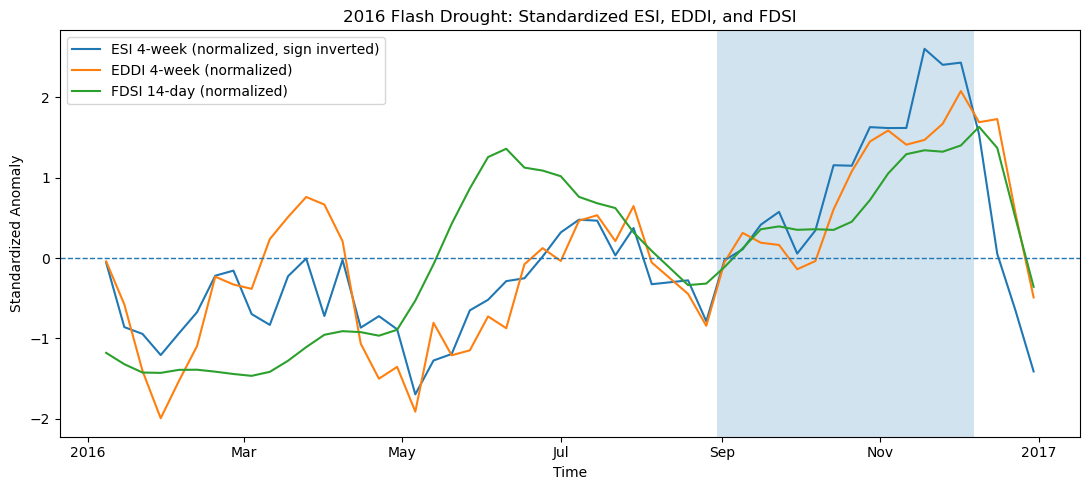

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

esi_norm_flipped.plot(ax=ax, label="ESI 4-week (normalized, sign inverted)")

eddi_norm.plot(ax=ax, label="EDDI 4-week (normalized)")

fdsi_norm.plot(ax=ax,label="FDSI 14-day (normalized)")

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("2016 Flash Drought: Standardized ESI, EDDI, and FDSI")
ax.axvspan("2016-08-30", "2016-12-07", alpha=0.2)
ax.set_ylabel("Standardized Anomaly")
ax.set_xlabel("Time")
ax.legend()

plt.tight_layout()
plt.show()

In [55]:
import pandas as pd



df = pd.DataFrame({
    "ESI": esi_norm_flipped.values,
    "EDDI": eddi_norm.values,
    "FDSI": fdsi_norm.values
}, index=esi_norm_flipped["time"].values)

corr_matrix = df.corr()
print(corr_matrix)

df_drought = df.loc["2016-08-30":"2016-12-07"]

corr_matrix_drought = df_drought.corr()
print(corr_matrix_drought)

           ESI      EDDI      FDSI
ESI   1.000000  0.844238  0.625354
EDDI  0.844238  1.000000  0.561448
FDSI  0.625354  0.561448  1.000000
           ESI      EDDI      FDSI
ESI   1.000000  0.938927  0.927657
EDDI  0.938927  1.000000  0.888795
FDSI  0.927657  0.888795  1.000000


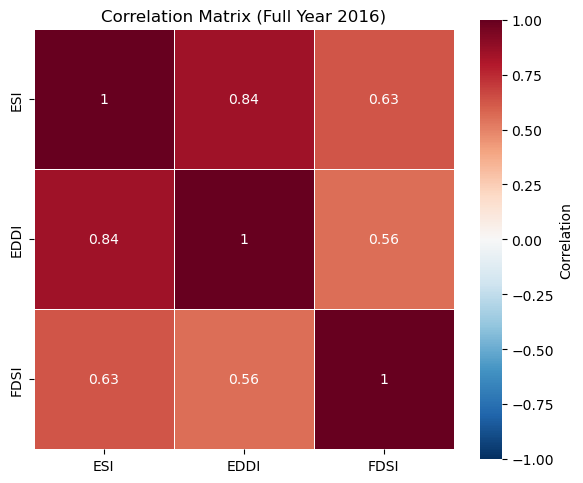

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Matrix (Full Year 2016)")
plt.tight_layout()
plt.show()

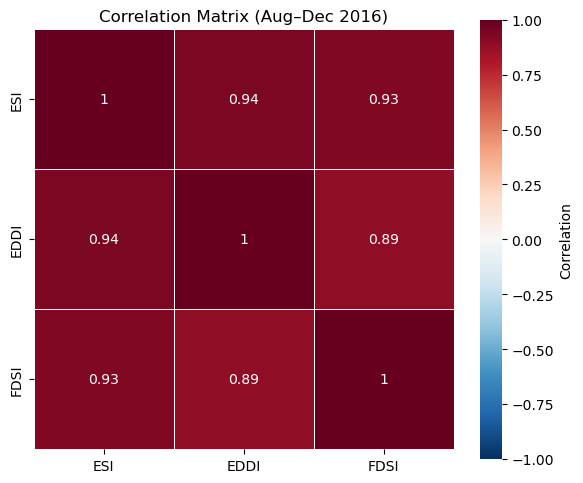

In [57]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix_drought,
    annot=True,
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Matrix (Aug–Dec 2016)")
plt.tight_layout()
plt.show()

In [68]:
event_start = "2016-08-30"
event_peak = "2016-12-07"

metrics = {}

for name, series in {
    "ESI": esi_norm_flipped,
    "EDDI": eddi_norm,
    "FDSI": fdsi_norm
}.items():

    s = series.sel(time=slice(event_start, event_peak))

    start_val = s.sel(time=event_start, method="nearest").item()
    peak_val = s.max().item()
    change = peak_val - start_val

    metrics[name] = {
        "Start value": start_val,
        "Peak value": peak_val,
        "Onset-to-peak change": change
    }

metrics_df = pd.DataFrame(metrics).T
print(metrics_df)


event_start = pd.Timestamp("2016-08-30")
event_peak = pd.Timestamp("2016-12-07")
days = (event_peak - event_start).days

metrics_df["Rate per day"] = metrics_df["Onset-to-peak change"] / days
metrics_df["Rate per week"] = metrics_df["Rate per day"] * 7

print(metrics_df)

      Start value  Peak value  Onset-to-peak change
ESI     -0.028254    2.603752              2.632006
EDDI    -0.051031    2.077659              2.128690
FDSI    -0.112286    1.401224              1.513510
      Start value  Peak value  Onset-to-peak change  Rate per day  \
ESI     -0.028254    2.603752              2.632006      0.026586   
EDDI    -0.051031    2.077659              2.128690      0.021502   
FDSI    -0.112286    1.401224              1.513510      0.015288   

      Rate per week  
ESI        0.186101  
EDDI       0.150513  
FDSI       0.107016  


In [69]:
from scipy.stats import linregress

slopes = {}

for name, series in {
    "ESI": esi_norm_flipped,
    "EDDI": eddi_norm,
    "FDSI": fdsi_norm
}.items():

    s = series.sel(time=slice("2016-08-30", "2016-12-07"))

    t = (s["time"] - s["time"][0]) / np.timedelta64(1, 'D')

    slope = linregress(t, s.values).slope
    slopes[name] = slope

print(slopes)

{'ESI': np.float64(0.03010793660960431), 'EDDI': np.float64(0.023993917302812015), 'FDSI': np.float64(0.01655422802108153)}


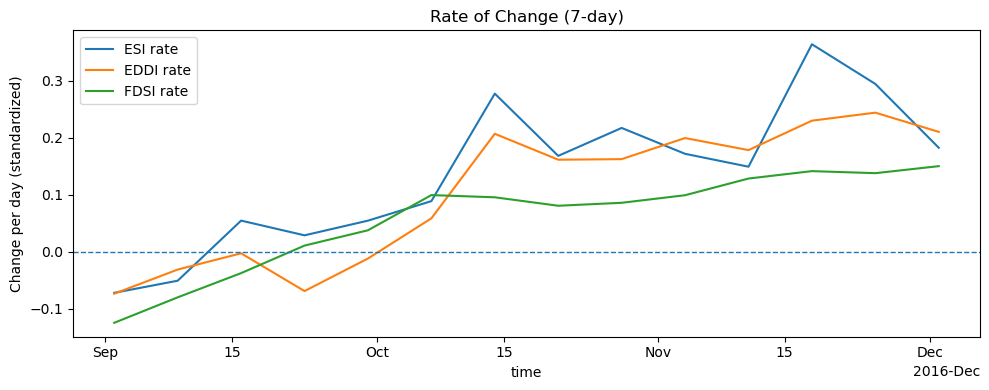

In [70]:
window = 7  # 7-day rate (clean and interpretable)

esi_rate = esi_norm_flipped.diff("time").rolling(time=window).mean()
eddi_rate = eddi_norm.diff("time").rolling(time=window).mean()
fdsi_rate = fdsi_norm.diff("time").rolling(time=window).mean()

# subset to drought period
esi_r = esi_rate.sel(time=slice("2016-08-30", "2016-12-07"))
eddi_r = eddi_rate.sel(time=slice("2016-08-30", "2016-12-07"))
fdsi_r = fdsi_rate.sel(time=slice("2016-08-30", "2016-12-07"))

fig, ax = plt.subplots(figsize=(10,4))

esi_r.plot(ax=ax, label="ESI rate")
eddi_r.plot(ax=ax, label="EDDI rate")
fdsi_r.plot(ax=ax, label="FDSI rate")

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("Rate of Change (7-day)")
ax.set_ylabel("Change per day (standardized)")
ax.legend()

plt.tight_layout()
plt.show()